A Random Forest regression model was trained to predict the calibration offset between radiocarbon age and true calendar age. The model uses isotopic features including F14C ratio, radiocarbon age, and Δ14C. The predicted offset is added to the radiocarbon age to estimate the calibrated calendar age.

Pipeline combines:

Physics equation

Age=−8033ln(F14C)

with

Machine learning calibration



# df["F14C"] = 1 + df["delta14c"] / 1000
Physics behind Δ14C

Δ14C (delta-14C) is a relative deviation of the isotopic ratio compared to a standard.

It is defined as:

Δ14𝐶=(𝑅_sample−𝑅_standard/𝑅_standard)*1000

Where:

𝑅=14𝐶/12𝐶
​
Units: per mil (‰) → parts per thousand

Rearranging the definition
𝑅_sample/𝑅_standard=1+Δ14𝐶/1000


This ratio is exactly what we call:

𝐹14𝐶=𝑁/𝑁0

a relative deviation (Δ14C)	​-> actual physical ratio (remaining fraction of Carbon-14)


# Theoretical Age Formula
===========================

`df["theoretical_c14_age"] = -8033 * np.log(df["F14C"])`

This comes directly from **radioactive decay physics**.

---

## Step-by-step derivation

### Radioactive decay law:


N(t) = N<sub>0</sub> e<sup>-λ t</sup>


---

### Divide both sides:


N/N<sub>0</sub> = e<sup>-λ t</sup>


---

### Take natural log:


N/N<sub>0</sub> = -λ t


---

### Rearrange:


t = 1/λ ln(N/N<sub>0</sub>)


---

## Substitute:


F^14C = N/N<sub>0</sub>


So:


t = 1/λ ln(F^14C)


---

## Where does 8033 come from?

For Carbon-14 decay:

- Half-life = **5730 years**

- Decay constant:


λ = ln 2/5730


---

### So:


1/λ= 8033  years


---

## Final formula:


t = -8033 ln(F^14C)


Dataset preview:
   cal_bp  c14_age  c14_sigma  delta14c  delta_sigma
0   55000    50100       1024     528.5        193.9
1   54980    50081       1018     528.3        192.7
2   54960    50063       1013     527.9        191.7
3   54940    50043       1007     527.8        190.6
4   54920    50027       1003     527.0        189.5
Dataset size: (9501, 5)

Model Evaluation Metrics
-----------------------
Mean Absolute Error (MAE): 2.635245407596669
Mean Squared Error (MSE): 30.77758386400347
Root Mean Squared Error (RMSE): 5.547754848945965
R² Score: 0.9999877154337206

Feature Importance:
c14_age     0.851227
delta14c    0.148773
dtype: float64

Test Example
------------
Input F14C Ratio: 0.5
Radiocarbon Age: 5568.05130143804
Calibrated Age: 5662.70130143804


c:\Users\lenovo\Desktop\mainr\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


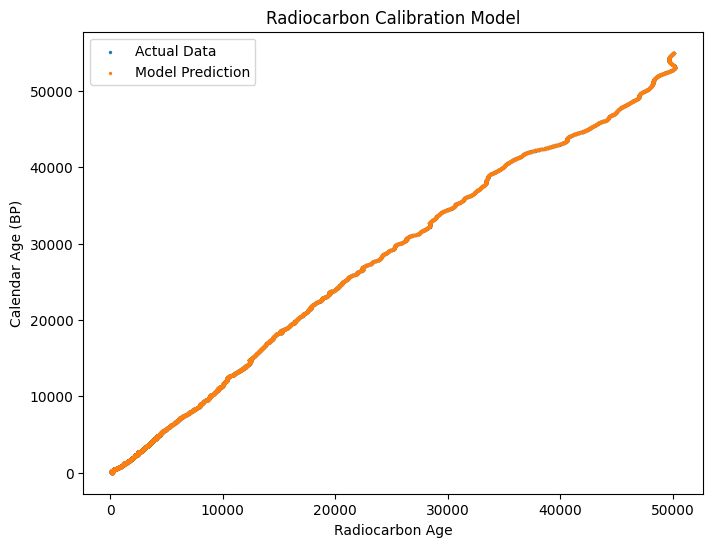

In [9]:
# ===============================
# Radiocarbon Dating Calibration Model
# ===============================

# Required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ===============================
# 1. Load Dataset
# ===============================

df = pd.read_csv("datacopy.csv")

df.columns = [
    "cal_bp",       # True calendar age (years BP)
    "c14_age",      # Radiocarbon age
    "c14_sigma",    # Measurement uncertainty
    "delta14c",     # Isotopic deviation
    "delta_sigma"
]

print("Dataset preview:")
print(df.head())
print("Dataset size:", df.shape)

# ===============================
# 2. Compute Radiocarbon Ratio
# ===============================

# Relative C14/C12 ratio
df["F14C"] = 1 + df["delta14c"] / 1000

# Theoretical decay age from physics formula
df["theoretical_c14_age"] = -8033 * np.log(df["F14C"])

# Calibration offset
df["offset"] = df["cal_bp"] - df["c14_age"]

# ===============================
# 3. Feature Selection
# ===============================

X = df[["c14_age", "delta14c"]] 

y = df["offset"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ===============================
# 4. Model Training
# ===============================

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

# ===============================
# 5. Model Evaluation
# ===============================

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("\nModel Evaluation Metrics")
print("-----------------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

# ===============================
# 6. Feature Importance
# ===============================

importance = model.feature_importances_

feature_importance = pd.Series(
    importance,
    index=X.columns
)

print("\nFeature Importance:")
print(feature_importance)

# ===============================
# 7. Prediction Function
# ===============================


def estimate_age_from_ratio(ratio):

    F14C = ratio

    # Compute radiocarbon age using decay equation
    c14_age = -8033 * np.log(F14C)

    # Estimate Δ14C
    delta14c = (F14C - 1) * 1000

    # Predict calibration offset
    offset = model.predict([[ c14_age, delta14c]])[0]

    # Final calibrated calendar age
    cal_age = c14_age + offset

    return c14_age, cal_age


# ===============================
# 8. Test Example
# ===============================

test_ratio = 0.5

rc_age, calibrated_age = estimate_age_from_ratio(test_ratio)

print("\nTest Example")
print("------------")
print("Input F14C Ratio:", test_ratio)
print("Radiocarbon Age:", rc_age)
print("Calibrated Age:", calibrated_age)

# ===============================
# 9. Visualization
# ===============================


# The calibration curve shows the relationship
# between measured radiocarbon age and the true calendar age. 
# Due to fluctuations in atmospheric carbon concentrations over time, 
# radiocarbon ages do not increase linearly with calendar ages. 
# The machine learning model predicts the calibration offset and 
# reconstructs a calibration curve similar to those used in established datasets such as IntCal.
plt.figure(figsize=(8, 6))

plt.scatter(df['c14_age'], df['cal_bp'], s=2, label="Actual Data")

pred_line = model.predict(X)

plt.scatter(df['c14_age'], df['c14_age'] +
            pred_line, s=2, label="Model Prediction")

plt.xlabel("Radiocarbon Age")
plt.ylabel("Calendar Age (BP)")
plt.title("Radiocarbon Calibration Model")

plt.legend()

plt.show()

| Metric       | Purpose                                               |
| ------------ | ----------------------------------------------------- |
| **MAE**      | Average absolute calibration error in years           |
| **MSE**      | Penalizes larger errors more strongly                 |
| **RMSE**     | Interpretable error magnitude in years                |
| **R² Score** | Measures how well model explains calibration variance |


This graph represents the residual error distribution between the predicted calendar age and the true calendar age.

Error=True Age−Predicted Age

Points near 0 → accurate predictions

Positive values → model underestimates age

Negative values → model overestimates age

A well-performing calibration model should show errors randomly distributed around zero without systematic bias.

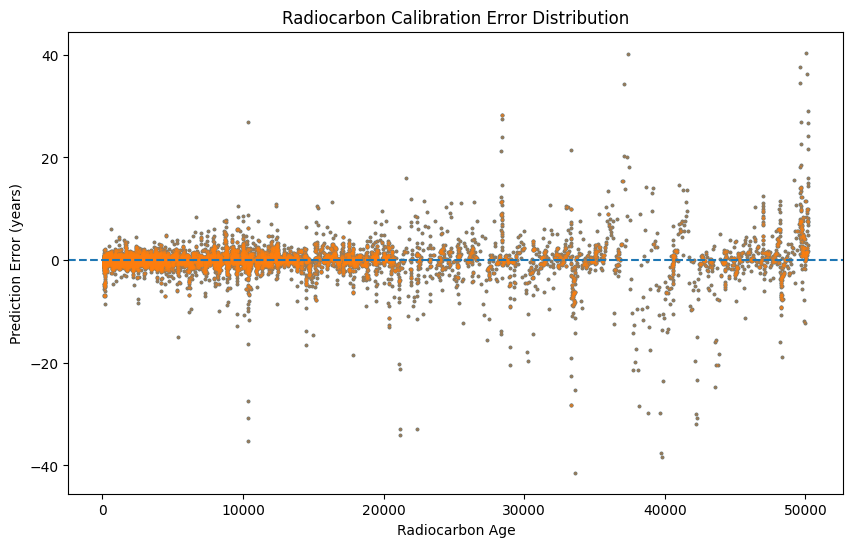

In [10]:
# ===============================
# Error Plot (Residual Analysis)
# ===============================

# Sort values for clean plotting
sorted_idx = np.argsort(df["c14_age"])

X_sorted = df["c14_age"].values[sorted_idx]
y_sorted = df["cal_bp"].values[sorted_idx]

# Predict calibration offset
pred_offset = model.predict(X)

# Convert offset prediction to calendar age
pred_curve = df["c14_age"] + pred_offset

pred_curve = pred_curve.values[sorted_idx]

# Residual errors
errors = y_sorted - pred_curve

# Plot
plt.figure(figsize=(10, 6))

plt.scatter(X_sorted, errors, s=3)

plt.axhline(0, linestyle="--")
plt.scatter(X_sorted, errors, s=3, alpha=0.4)
plt.xlabel("Radiocarbon Age")
plt.ylabel("Prediction Error (years)")

plt.title("Radiocarbon Calibration Error Distribution")

plt.show()

The Predicted Age vs True Age plot compares the calibrated ages predicted by the machine learning model with the actual calendar ages from the dataset. The dashed diagonal line represents perfect predictions where predicted age equals the true age. Points closer to this line indicate higher model accuracy, while deviations represent prediction errors.

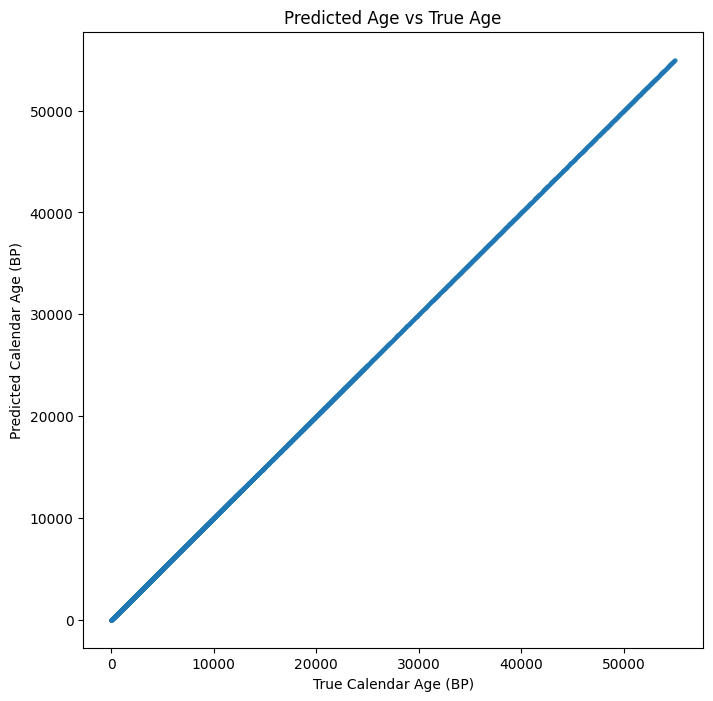

In [11]:
# ===============================
# Predicted Age vs True Age Plot
# ===============================

# True calendar ages
y_true = df["cal_bp"]

# Model predicted offset
pred_offset = model.predict(X)

# Convert to predicted calendar age
y_pred = df["c14_age"] + pred_offset

plt.figure(figsize=(8,8))

plt.scatter(y_true, y_pred, s=4, alpha=0.4)

# Perfect prediction line
min_age = min(y_true.min(), y_pred.min())
max_age = max(y_true.max(), y_pred.max())

plt.plot([min_age, max_age], [min_age, max_age], linestyle="--")

plt.xlabel("True Calendar Age (BP)")
plt.ylabel("Predicted Calendar Age (BP)")
plt.title("Predicted Age vs True Age")

plt.show()

Although the predicted vs true age plot shows strong agreement, the residual error plot reveals localized deviations. This indicates that while the model captures the overall calibration trend, some age ranges exhibit systematic prediction errors due to non-linear variations in atmospheric radiocarbon concentration.